##### 构建一个大语言模型架构

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK']='TRUE'

import torch
import torch.nn as nn
import tiktoken


GPT_CONFIG_124M = {
    "vocab_size": 50257,     # 词汇表大小
    "context_length": 1024,  # 上下文长度
    "emb_dim": 768,          # 嵌入维度
    "n_heads": 12,           # 注意力头的数量
    "n_layers": 12,          # 层数
    "drop_rate": 0.1,        # dropout率
    "qkv_bias": False,       # 查询-键-值偏置
}

#### 代码清单 4-1 一个包含占位符的GPT模型架构类

In [2]:
class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # 使用占位符替换 TransformerBlock
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg)
              for _ in range(cfg["n_layers"])]
        )

        # 使用占位符替换层归一化
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_dex):
        batch_size,seq_len = in_dex.shape
        tok_embeds =self.tok_emb(in_dex)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device = in_dex.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

# 一个简单的占位符类，稍后将被真正的TransformerBlock替换
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    # 这个代码块不执行任何操作，只返回其输入
    def forward(self, x):
        return x

# 一个简单的占位符类，稍后将被真正的层归一化替换
class DummyLayerNorm(nn.Module):
    # 这里的参数只是为了模仿层归一化的接口
    def __init__(self, normalized_shape, eps=1e-5,):
        super().__init__()

    def forward(self, x):
        return x

In [4]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim = 0)
print(batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("Output shape:", logits.shape)
print(logits)

Output shape: torch.Size([2, 4, 50257])
tensor([[[-0.9289,  0.2748, -0.7557,  ..., -1.6070,  0.2702, -0.5888],
         [-0.4476,  0.1726,  0.5354,  ..., -0.3932,  1.5285,  0.8557],
         [ 0.5680,  1.6053, -0.2155,  ...,  1.1624,  0.1380,  0.7425],
         [ 0.0447,  2.4787, -0.8843,  ...,  1.3219, -0.0864, -0.5856]],

        [[-1.5474, -0.0542, -1.0571,  ..., -1.8061, -0.4494, -0.6747],
         [-0.8422,  0.8243, -0.1098,  ..., -0.1434,  0.2079,  1.2046],
         [ 0.1355,  1.1858, -0.1453,  ...,  0.0869, -0.1590,  0.1552],
         [ 0.1666, -0.8138,  0.2307,  ...,  2.5035, -0.3055, -0.3083]]],
       grad_fn=<UnsafeViewBackward0>)


##### 使用层归一化进行归一化激活

In [6]:
torch.manual_seed(123)
batch_example = torch.randn(2, 5)  # 创建两个训练样本，每个样本包含5个维度
layer = nn.Sequential(nn.Linear(5,6), nn.ReLU())
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [8]:
mean = out.mean(dim=-1, keepdim = True)
var = out.var(dim=-1, keepdim = True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [9]:
out_norm =(out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim = True)
var = out_norm.var(dim=-1, keepdim = True)
print("Normalized layer Outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer Outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[9.9341e-09],
        [0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [10]:
# 为了提高可读性，可以通过将 sci_mode 设置为 False 来关闭科学计数法，从而在打印张量值时避免使用科学记数法
torch.set_printoptions(sci_mode=False)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[    0.0000],
        [    0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

#### 代码清单 4-2 层归一化类

In [12]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim = -1, keepdim = True)
        var = x.var(dim = -1, keepdim = True, unbiased = False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [13]:
batch_example = torch.randn(2, 5)
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim = -1, keepdim = True)
var = out_ln.var(dim = -1, unbiased = False, keepdim = True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[     0.0000],
        [    -0.0000]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.9998],
        [0.9999]], grad_fn=<VarBackward0>)


##### 实现具有 GELU 激活函数的前馈神经网络

#### 代码清单 4-3 GELU激活函数的实现

In [14]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))

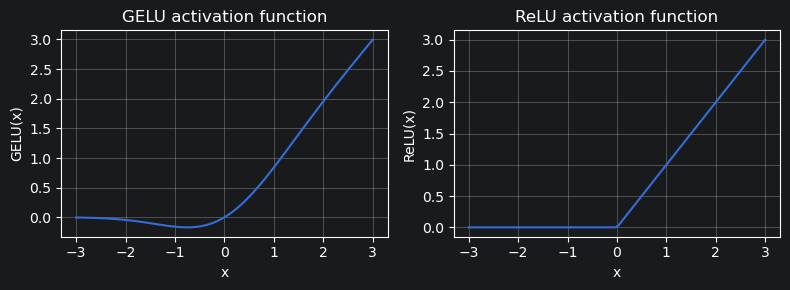

In [15]:
# 为了直观地比较 GELU 函数与 RELU 函数，可以将它们并排绘制出来
import matplotlib.pyplot as plt
gelu , relu = GELU(), nn.ReLU()
# 在 -3 和 3 之间创建 100 个样本数据点
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize = (8, 3))
for i, (y, label) in enumerate(zip([ y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
plt.tight_layout()
plt.show()

#### 代码清单 4-4 前馈神经网络模块

In [16]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], cfg["emb_dim"] * 4),
            GELU(),
            nn.Linear(cfg["emb_dim"] * 4, cfg["emb_dim"]),
        )

    def forward(self, x):
        return self.layers(x)

In [17]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)  # 创建批次维度为 2 的样本输入
out = ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


##### 添加快捷连接

#### 代码清单 4-5 用于演示快捷连接的神经网络

In [18]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # 五个层的实现
        self.layers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(layer_sizes[0], layer_sizes[1]),
                GELU(),
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[1], layer_sizes[2]),
                GELU(),
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[2], layer_sizes[3]),
                GELU(),
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[3], layer_sizes[4]),
                GELU(),
            ),
            nn.Sequential(
                nn.Linear(layer_sizes[4], layer_sizes[5]),
                GELU(),
            )
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

In [19]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)  # 指定随机种子用于初始化权重，以确保结果可复现
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes, use_shortcut= False
)

In [20]:
# 实现一个用于在模型的反向传播过程中计算梯度的函数
def print_gradients(model, x):
    output = model(x)  # 前向传播
    target = torch.tensor([[0.]])

    loss = nn.MSELoss ()
    loss = loss(output, target)  # 基于目标和输出之间的差距来计算损失

    loss.backward()  # 反向传播来计算梯度

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [21]:
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173587836325169
layers.1.0.weight has gradient mean of 0.0001201116101583466
layers.2.0.weight has gradient mean of 0.0007152041653171182
layers.3.0.weight has gradient mean of 0.001398873864673078
layers.4.0.weight has gradient mean of 0.005049646366387606


In [22]:
# 实例化一个包含跳跃连接的模型，并观察它的比较结果
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694106817245483
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732502937317
layers.4.0.weight has gradient mean of 1.3258541822433472


##### 连接 Transformer 块中的注意力层和线性层

#### 代码清单 4-6 GPT 的 Transformer 块组件

In [23]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in = cfg["emb_dim"],
            d_out = cfg["emb_dim"],
            context_length = cfg["context_length"],
            num_heads = cfg["n_heads"],
            dropout = cfg["drop_rate"],
            qkv_bias = cfg["qkv_bias"],
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # 在注意力块中添加快捷连接
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = shortcut + x  # 将原始输入添加回来

        # 在前馈层中添加快捷链接
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = shortcut + x
        return x

In [24]:
torch.manual_seed(123)
# 创建形状为 [batch_size, num_tokens, emb_dim] 的样例输入
x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


##### 实现 GPT 模型

#### 代码清单 4-7 GPT模型架构的实现

In [25]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_dex):
        batch_size, seq_len = in_dex.shape
        tok_embeds = self.tok_emb(in_dex)

        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_dex.device)  # device 的设置允许我们在 CPU 或 GPU 上训练模型，具体取决于输入数据所在的设备
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim = 0)

out = model(batch)
print("Input shape:\n", batch)
print("Output shape:\n", out.shape)
print(out)

Input shape:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape:
 torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


In [27]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [28]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])


In [29]:
total_params_gpt2 = (
    total_params - sum(p.numel()
                       for p in model.out_head.parameters())
)
print(f"Number of trainable parameters "
      f"considering weight tying: {total_params_gpt2:,}"
)

Number of trainable parameters considering weight tying: 124,412,160


In [30]:
total_size_bytes = total_params * 4  # 计算总的字节大小（假设每个参数时占用 4 字节的 32 位浮点数）
total_size_mb = total_size_bytes / (1024 ** 2)  # 转换为兆字节（MB）
print(f"Total size of the model: {total_size_mb:.2f} MB")

Total size of the model: 621.83 MB


##### 生成文本

#### 代码清单 4-8 GPT 模型中用于生成文本的函数

In [31]:
def generate_text_simple(model, idx,  # idx 是当前文本的索引数组，其形状为(batch, n_tokens)
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]  # 将当前文本截断至支持的长度。如果大语言模型仅支持 5 个词元，但此时文本长度为 10，则只有最后 5 个词元会被用作输入文本
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]  # 只关注最后一个输出的内容，因此形状会从 (batch, n_token, vocab_size) 变为 (batch, vocab_size)
        probas = torch.softmax(logits, dim=-1)  # probas 的形状为 (batch, vocab_size)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # idx_next 的形状为 (batch, 1)
        idx = torch.cat((idx, idx_next), dim=1)  # 将计算出的下一个字符的索引添加到索引数组中，此时 idx 的形状会变为 (batch, n_tokens + 1)

    return  idx

In [32]:
start_context = "Hello, I am"
encoded = tokenizer.encode(start_context)
print("encoded:",  encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # 添加 batch 维度
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [15496, 11, 314, 716]
encoded_tensor.shape: torch.Size([1, 4])


In [33]:
model.eval()  # 不训练模型时关闭 dropout
out = generate_text_simple(
    model = model,
    idx = encoded_tensor,
    max_new_tokens = 6,
    context_size = GPT_CONFIG_124M["context_length"],
)
print("Output:", out)
print("Output length:", len(out[0]))

Output: tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Output length: 10


In [34]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswickattribute argue
